In [184]:
import os
import pandas as pd
import numpy as np
import networkx as nx 
import matplotlib.pyplot as plt
import torch
from networkx.algorithms.community import modularity
from community import community_louvain 


In [185]:
def clean_gt_file_names(importance_ranking):

    """ Gets torch files of ground truth and replaces any old twitter
        usernames with the new ones to match the df_data """

    # Load the DataFrame with member data
    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')

    # Fill NA values in 'new_twitter_name' with values from 'twitter_name'
    members['new_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    # Create a dictionary mapping from the old Twitter names to the new Twitter names
    name_mapping = dict(zip(members['twitter_name'], members['new_twitter_name']))

    # Initialize a new dictionary to hold the updated importance ranking
    updated_importance_ranking = {}

    # Update the dictionary keys
    for old_name, value in importance_ranking.items():
        # Get the new Twitter name if available, otherwise keep the old name
        new_name = name_mapping.get(old_name, old_name)
        updated_importance_ranking[new_name] = value

    # Assign the updated dictionary back to importance_ranking
    return updated_importance_ranking

# Print the updated importance ranking to check
# importance_ranking = torch.load('01_normalized_congress_member_to_affiliation_score.pth')


In [186]:
def assign_strength(df, inflection_point, party_flag):
    """ Assigns 'strong' or 'weak' based on the affiliation score. """
    if party_flag == 'R':
        return 'strong' if df['affiliation_score'] >= inflection_point else 'weak'
    else:  # 'D'
        return 'strong' if df['affiliation_score'] <= inflection_point else 'weak'

In [187]:
def build_bipartite_network(df_data):

    """ Builds directed network using politicians and their followings as nodes
    and directed edges based on if one node follows the other. Used for finding importance
    of websites to filter network """

    G = nx.DiGraph()

    # Add edges based on the politicians and the people they follow
    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']
        following_list = row['following']  # List of people the politician follows
        
        # Add the politician as a node
        G.add_node(politician, party=row['party'])
        
        # Add edges for each person the politician follows
        for followee in following_list:
            G.add_node(followee)  # Add the followed account as a node
            G.add_edge(politician, followee)  # Directed edge from politician to followed account
    
    return G

In [188]:
def build_network(df_data, k, hits, weighted):

    """ Builds network of politicians, with edges between them if they share k followers """

    G = nx.Graph()
    
    # Add nodes
    names = df_data['current_twitter_name'].tolist()

    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']        
        G.add_node(politician, party=row['party'], strength=row['strength'])
    
    # Add edges based on shared following
    for i in range(len(df_data)):
        for j in range(i + 1, len(df_data)):
            # Get the sets of following of each politician
            # Uses the "important_following" column if we incorporate hits, otherwise defaults to the "following" column
            if hits:
                following_i = set(df_data.iloc[i]['important_following'])
                following_j = set(df_data.iloc[j]['important_following'])
            else:
                following_i = set(df_data.iloc[i]['following'])
                following_j = set(df_data.iloc[j]['following'])
            
            # Get the shared following
            shared_following = following_i.intersection(following_j)
            if len(shared_following) >= k:
                if weighted == False:
                    G.add_edge(names[i], names[j])
                else:
                    G.add_edge(names[i], names[j], weight=len(shared_following))
    
    return G

In [189]:
def read_data(num_nodes=-1):

    """ Reads data of politician, their party and who they follow into df_data """

    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')
    members['current_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    df_data = pd.DataFrame()
    df_data[['current_twitter_name','party']] = members[['current_twitter_name','party']].copy()
    if num_nodes != -1:
        df_data = df_data.head(num_nodes)

    following_data = []
    
    for twitter_name in df_data['current_twitter_name']:
        filename = f"twitterExport_{twitter_name}_Following.csv"
        filepath = os.path.join('raw_data/raw_data/following_data_raw', filename)

        if os.path.exists(filepath):
            followed_users = pd.read_csv(filepath)['user_name'].tolist()
        else:
            followed_users = []
        
        following_data.append(followed_users)

    df_data['complete_following'] = following_data
    df_data = df_data[df_data['complete_following'].apply(lambda x: x != [])]

    # Convert the list of all current twitter names to a set for faster lookup
    current_names_set = set(df_data['current_twitter_name'].values)

    # Filter out following names that also appear in df_data['current_twitter_name']
    filtered_following_data = []
    for follow_list in df_data['complete_following']:
        filtered_list = [name for name in follow_list if name not in current_names_set]
        filtered_following_data.append(filtered_list)

    df_data['following'] = filtered_following_data
    df_data = df_data[df_data['following'].apply(lambda x: x != [])]
    
    republican_df = df_data[df_data['party'] == "R"]
    democratic_df = df_data[df_data['party'] == "D"]
    importance_ranking = clean_gt_file_names(torch.load('01_normalized_congress_member_to_affiliation_score.pth'))
    df_data['affiliation_score'] = df_data['current_twitter_name'].map(importance_ranking)
    df_data['strength'] = df_data.apply(lambda x: assign_strength(x, 0.75 if x['party'] == 'R' else -0.75, x['party']), axis=1)

    return df_data, republican_df, democratic_df

In [ ]:
def degree_lower_2_remover(df_data,G_bipartite):
    degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes()}
    # Filtering nodes based on threshold
    filtered_followees = {node for node, score in degree_centrality.items() if score >= 2}
    df_data['following'] = df_data['following'].apply(lambda followings: [f for f in followings if f in filtered_followees])


In [209]:
def degree_lower_n_remover(df_data,G_bipartite,n):
    degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes()}
    # Filtering nodes based on threshold
    filtered_followees = {node for node, score in degree_centrality.items() if score >= n}
    df_data['following'] = df_data['following'].apply(lambda followings: [f for f in followings if f in filtered_followees])


In [191]:
def classify_communities(alignment):
    ratio_list = []
    community_label = {}
    for community_id, parties_total in alignment.items():
        ratio = parties_total['R']/(parties_total['R']+parties_total['D'])
        ratio_list.append(ratio)

    if ratio_list[0]>ratio_list[1]:
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    community_label[Republican] = 'Republican'
    community_label[Democrat] = 'Democrat' 
    # print(ratio_list, community_label)
    return community_label
    

In [192]:
def merge_n_communities_by_edge_count(G, communities, no_communities):
    """Merge a list of communities into exactly n_communities based on the edge counts between them.

    Args:
        G (networkx.Graph): The graph from which the communities are derived.
        communities (list of set): List of communities to merge, where each community is a set of nodes.
        no_communities (int): Desired number of communities after merging.

    Returns:
        list of set: Communities merged based on edge connectivity.
    """
    
    if len(communities) < no_communities:
        raise ValueError("The number of initial communities must be at least equal to the desired number of final communities.")

    # Convert frozensets or other iterables to sets if necessary
    communities = [set(community) for community in communities]

    # Sort communities by size in descending order
    communities = sorted(communities, key=len, reverse=True)

    # Start with the largest communities as determined by 'no_communities'
    largest_communities = communities[:no_communities]
    remaining_communities = communities[no_communities:]

    # Function to count edges between two sets of nodes
    def count_edges_between(set1, set2):
        return sum(1 for node in set1 if set(G.neighbors(node)) & set2)

    # Merge remaining communities into the largest based on edge counts
    for community in remaining_communities:
        max_edges = -1
        best_target_idx = -1

        # Determine which of the largest communities this should merge with
        for i, large_community in enumerate(largest_communities):
            edge_count = count_edges_between(community, large_community)
            if edge_count > max_edges:
                max_edges = edge_count
                best_target_idx = i

        # Merge the community into the best matching largest community
        largest_communities[best_target_idx].update(community)
    return largest_communities


In [193]:
# NEW VERSION CHECK IF WORKS AND THEN TRY IMPLEMENT THE OTHERS

def louvain_two_communities(G):

    """ Run the Louvain algorithm to detect communities """

    partition = community_louvain.best_partition(G)


    initial_communities = {}
    for node, community in partition.items():
        if community not in initial_communities:
            initial_communities[community] = set()
        initial_communities[community].add(node)

    # Convert dictionary of communities into a list of sets
    communities_list = list(initial_communities.values())
    print(len(communities_list))

    # Step 3: Merge communities into two based on edge connectivity
    if len(communities_list) > 2:
        # communities = merge_communities_by_edge_count(G, communities_list)
        communities = merge_n_communities_by_edge_count(G, communities_list, 2)
        # communities = merge_communities_max_modularity(G, communities_list)
        # communities = merge_into_two_communities(communities_list)
    else:
        communities = communities_list
    # Create the final two-community split
    node_to_community = {}
    for node in communities[0]:
        node_to_community[node] = 1
    for node in communities[1]:
        node_to_community[node] = 2

    # Calculate modularity value
    try:
        mod_value = modularity(G, communities)
    except:
        mod_value = 0

    return communities, mod_value

In [194]:
def political_alignment(G, communities):
    """
    Analyze alignment with political parties for a given set of communities.

    Args:
        G (networkx.Graph): The graph from which the communities are derived, with nodes having a 'party' attribute.
        communities (list of set): List of communities, where each community is a set of nodes.

    Returns:
        dict: Dictionary containing the political alignment of each community.
    """
    # Initialize an alignment dictionary for all communities
    alignment = {}
    for idx, community in enumerate(communities, start=1):
        # Initialize party counts for the current community
        alignment[idx] = {'R': 0, 'D': 0}
        for node in community:
            if 'party' in G.nodes[node]:  # Check if the 'party' attribute exists
                party = G.nodes[node]['party']
                if party in alignment[idx]:  # Increment the party count if it's either 'R' or 'D'
                    alignment[idx][party] += 1
                else:  # Optional: initialize other party labels dynamically
                    alignment[idx][party] = 1

    return alignment


In [195]:
def calculate_metrics(alignment, community_label):
    """
    Calculate FFC, ARI, RI, and NMI from alignment data and graph nodes.

    Parameters:
        alignment (dict): Alignment data of communities to political parties.
        node_to_community (dict): Mapping of nodes to their assigned community.
        G (Graph): The graph with nodes and party information.

    Returns:
        dict: Calculated metrics.
    """
    # print(community_label[1])
    if community_label[1] == 'Republican':
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    # print(Republican, Democrat)
    # Extract counts
    true_positive_R = alignment[Republican]["R"]
    false_positive_R = alignment[Republican]["D"]
    true_positive_D = alignment[Democrat]["D"]
    false_positive_D = alignment[Democrat]["R"]
    # Precision and Recall for R
    precision_R = true_positive_R / (true_positive_R + false_positive_R) if (true_positive_R + false_positive_R) > 0 else 0
    recall_R = true_positive_R / (true_positive_R + false_positive_D) if (true_positive_R + false_positive_D) > 0 else 0
    
    # Precision and Recall for D
    precision_D = true_positive_D / (true_positive_D + false_positive_D) if (true_positive_D + false_positive_D) > 0 else 0
    recall_D = true_positive_D / (true_positive_D + false_positive_R) if (true_positive_D + false_positive_R) > 0 else 0

    # Macro Average (Optional)
    precision_macro = (precision_R + precision_D) / 2
    recall_macro = (recall_R + recall_D) / 2

    f1_score = 2*precision_macro*recall_macro/(precision_macro+recall_macro)  if (precision_macro+recall_macro) > 0 else 0
    accuracy = (true_positive_R+true_positive_D)/(true_positive_D+true_positive_R+false_positive_R+false_positive_D)


    return {
        "accuracy": accuracy,
        "f1": f1_score
    }


In [196]:
def calc_hits_values(G, df_data):
    # Compute HITS scores
    hub_scores, authority_scores = nx.hits(G, max_iter=100, tol=1e-7)
    
    # Store the HITS scores as node attributes
    for node in G.nodes():
        if node not in df_data['current_twitter_name'].values:
            G.nodes[node]['hub_score'] = hub_scores.get(node, 0)
            G.nodes[node]['authority_score'] = authority_scores.get(node, 0)
        else:
            authority_scores.pop(node)
            hub_scores.pop(node)
    
    # returning below to easily calc percentiles etc
    return authority_scores, hub_scores

In [232]:
def compare_metrics_fixed_network(
    df_data,
    shared_following_thresholds=list(range(2,12,2)),
    degree_thresholds=list(range(1, 11, 1)),
    authority_percentiles=list(range(0, 30, 2))
):
    # G_directed = build_bipartite_network(df_data)
    G_directed_old = build_bipartite_network(df_data)
    degree_lower_2_remover(df_data, G_directed_old)
    G_directed = build_bipartite_network(df_data)
    authority_scores, _ = calc_hits_values(G_directed, df_data)
    degree_scores = {node: G_directed.degree(node) for node in G_directed.nodes()}

    metrics_result = {
        'degree': {},
        'authority': {},
        'no_filtering': {}
    }
    # No Filtering
    df_data['important_following'] = df_data['following']
    G = build_network(df_data, k=26, hits=True, weighted=True)
    communities, mod_value = louvain_two_communities(G)
    alignment = political_alignment(G, communities)
    comm_labels = classify_communities(alignment)
    metrics = calculate_metrics(alignment, comm_labels)
    isolated_nodes = sum(1 for _, d in G.degree() if d == 0)
    edge_counts = G.number_of_edges()

    metrics_result['no_filtering'][26] = {
        'accuracy': metrics['accuracy'],
        'f1': metrics['f1'],
        'modularity': mod_value,
        'isolated': isolated_nodes,
        'edge_count': edge_counts
    }
    
    for k_val in shared_following_thresholds:
        print(f"\n=== Shared-Following Threshold k = {k_val} ===")

        

        # DEGREE
        degree_metrics = {'thresholds': [], 'accuracy': [], 'f1': [], 'modularity': [], 'isolated': [], 'edge_count': []}
        for t in degree_thresholds:
            filtered = {node for node, val in degree_scores.items() if val >= t-1}
            df_data['important_following'] = df_data['following'].apply(
                lambda f_list: [f for f in f_list if f in filtered]
            )
            G = build_network(df_data, k=k_val, hits=True, weighted=True)
            communities, mod_value = louvain_two_communities(G)
            alignment = political_alignment(G, communities)
            comm_labels = classify_communities(alignment)
            metrics = calculate_metrics(alignment, comm_labels)
            isolated_nodes = sum(1 for _, d in G.degree() if d == 0)
            edge_counts = G.number_of_edges()

            degree_metrics['thresholds'].append(t)
            degree_metrics['modularity'].append(mod_value)
            degree_metrics['accuracy'].append(metrics['accuracy'])
            degree_metrics['f1'].append(metrics['f1'])
            degree_metrics['isolated'].append(isolated_nodes)
            degree_metrics['edge_count'].append(edge_counts)
        metrics_result['degree'][k_val] = degree_metrics

        # AUTHORITY
        authority_metrics = {'thresholds': [], 'accuracy': [], 'f1': [], 'modularity': [], 'isolated': [], 'edge_count': []}
        for p in authority_percentiles:
            threshold_value = np.percentile(list(authority_scores.values()), p)
            filtered = {node for node, val in authority_scores.items() if val >= threshold_value}
            df_data['important_following'] = df_data['following'].apply(
                lambda f_list: [f for f in f_list if f in filtered]
            )
            G = build_network(df_data, k=k_val, hits=True, weighted=True)
            communities, mod_value = louvain_two_communities(G)
            alignment = political_alignment(G, communities)
            comm_labels = classify_communities(alignment)
            metrics = calculate_metrics(alignment, comm_labels)
            isolated_nodes = sum(1 for _, d in G.degree() if d == 0)
            edge_counts = G.number_of_edges()
            authority_metrics['thresholds'].append(p)
            authority_metrics['modularity'].append(mod_value)
            authority_metrics['accuracy'].append(metrics['accuracy'])
            authority_metrics['f1'].append(metrics['f1'])
            authority_metrics['isolated'].append(isolated_nodes)
            authority_metrics['edge_count'].append(edge_counts)
        metrics_result['authority'][k_val] = authority_metrics

    return metrics_result


In [233]:
def plot_isolated_nodes(results, metric_type):
    plt.figure(figsize=(8, 5))

    for k in results[metric_type].keys():
        thresholds = results[metric_type][k]['thresholds']
        isolated = results[metric_type][k]['isolated']
        plt.plot(thresholds, isolated, marker='o', label=f'k={k}')

    for k in results['no_filtering']:
        baseline = results['no_filtering'][k]['isolated']
        plt.axhline(y=baseline, linestyle='--', color='gray', alpha=0.5, label=f'No filtering (k={k})')

    plt.title(f"Number of Isolated Nodes vs {metric_type.title()} Threshold")
    plt.xlabel(f"{'Percentile' if metric_type == 'authority' else 'Degree'} Threshold")
    plt.ylabel("Isolated Nodes")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [234]:
def plot_edge_counts(results, metric_type):
    plt.figure(figsize=(8, 5))

    for k in results[metric_type]:
        thresholds = results[metric_type][k]['thresholds']
        edges = results[metric_type][k]['edge_count']
        plt.plot(thresholds, edges, marker='o', label=f'k={k}')

    # Plot horizontal baseline for each shared-following threshold
    for k in results['no_filtering']:
        baseline = results['no_filtering'][k]['edge_count']
        plt.axhline(y=baseline, linestyle='--', color='gray', alpha=0.5, label=f'No filtering (k={k})')

    plt.title(f"Edge Count vs {metric_type.title()} Threshold")
    plt.xlabel(f"{'Percentile' if metric_type == 'authority' else 'Degree'} Threshold")
    plt.ylabel("Number of Edges")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [235]:
df_data, republican_df, democratic_df = read_data(-1)

df_data

,current_twitter_name,party,complete_following,following,affiliation_score,strength
1,SpeakerRyan,R,"[DarrellIssa, WaysandMeansGOP, cathymcmorris, ...","[DarrellIssa, WaysandMeansGOP, RepKevinBrady, ...",0.969697,strong
2,SpeakerPelosi,D,"[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...","[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...",-0.885246,strong
3,michelebachmann,R,"[DavidLimbaugh, RedState, Heritage, ScottWalke...","[DavidLimbaugh, RedState, Heritage, ScottWalke...",0.965217,strong
4,dwstweets,D,"[donnabrazile, Eugene_Robinson, JaredEMoskowit...","[donnabrazile, Eugene_Robinson, JaredEMoskowit...",-0.878049,strong
5,EricCantor,R,"[EWErickson, foxnewspolitics, SpeakerBoehner, ...","[EWErickson, foxnewspolitics, SpeakerBoehner, ...",0.976000,strong
...,...,...,...,...,...,...
176,stabenow,D,"[SenStabenow, SenGaryPeters, gretchenwhitmer, ...","[SenStabenow, SenGaryPeters, gretchenwhitmer, ...",-0.643939,weak
179,sen_joemanchin,D,"[SenatorSinema, lisamurkowski, WVGovernor, Sen...","[SenatorSinema, WVGovernor, SenCapito, SenJoni...",-0.584615,weak
180,sendancoats,R,"[AttyAbdul, lisamurkowski, nkellyIN, marybschn...","[AttyAbdul, nkellyIN, marybschneider, camsavag...",0.707692,weak
181,mcconnellpress,R,"[LeaderMcConnell, RyanQuarlesKY, KYGOP, SenJoh...","[LeaderMcConnell, RyanQuarlesKY, KYGOP, SenJoh...",0.628788,weak


In [236]:
results = compare_metrics_fixed_network(df_data)

# for metric in ['modularity', 'accuracy', 'f1']:
#     plot_metric_sweep(results, metric_name=metric, metric_type='degree')
#     plot_metric_sweep(results, metric_name=metric, metric_type='authority')



# plot_edge_counts(results, 'degree')
# plot_edge_counts(results, 'authority')

# plot_isolated_nodes(results, 'degree')
# plot_isolated_nodes(results, 'authority')


4

=== Shared-Following Threshold k = 2 ===
2
2
2
2
3
3
3
3
3
3
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2

=== Shared-Following Threshold k = 4 ===
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3

=== Shared-Following Threshold k = 6 ===
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4

=== Shared-Following Threshold k = 8 ===
4
4
4
4
4
5
5
5
5
5
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4

=== Shared-Following Threshold k = 10 ===
4
4
4
4
4
5
5
5
5
5
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4


In [237]:
print(list(range(0, 100, 5)))
print(list(range(2, 27, 3)))
print(list(range(2, 12, 2)))


[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
[2, 5, 8, 11, 14, 17, 20, 23, 26]
[2, 4, 6, 8, 10]


In [272]:
import matplotlib.pyplot as plt

def plot_metric_comparison_subplots(results, metric_name, y_label, title):
    """
    Creates side-by-side subplots comparing degree-based and authority-based thresholding
    for a given metric across different shared-following thresholds (k values), including
    a no-filtering baseline for k=26.
    """
    fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    # Collect global Y limits across both metric types
    all_vals = []
    for metric_type in ['degree', 'authority']:
        for k in results[metric_type].keys():
            all_vals.extend(results[metric_type][k][metric_name])
    all_vals.append(results['no_filtering'][26][metric_name])  # include baseline in y-range
    y_min, y_max = min(all_vals), max(all_vals)

    for i, metric_type in enumerate(['degree', 'authority']):
        for k in results[metric_type]:
            thresholds = results[metric_type][k]['thresholds']
            values = results[metric_type][k][metric_name]
            axs[i].plot(thresholds, values, marker='o', label=f'k = {k}')

        # Add horizontal baseline for k = 26 (no filtering)
        baseline = results['no_filtering'][26][metric_name]
        axs[i].axhline(y=baseline, color='black', linestyle='--', linewidth=3, label='Baseline (k=26)')

        axs[i].set_title(f"{title} vs {metric_type.title()} Threshold")
        axs[i].set_xlabel("Threshold" if metric_type == 'degree' else "Percentile Threshold")
        axs[i].set_ylabel(y_label)
        offset = 0
        if metric_name == 'modularity':
            offset = 0.0025
        elif metric_name == 'edge_count':
            offset = 500
        else:
            offset = 1
        axs[i].set_ylim(max(-0.1,y_min - offset), y_max + offset)
        
        axs[i].grid(True)
    axs[i].legend()

    plt.tight_layout()
    plt.show()


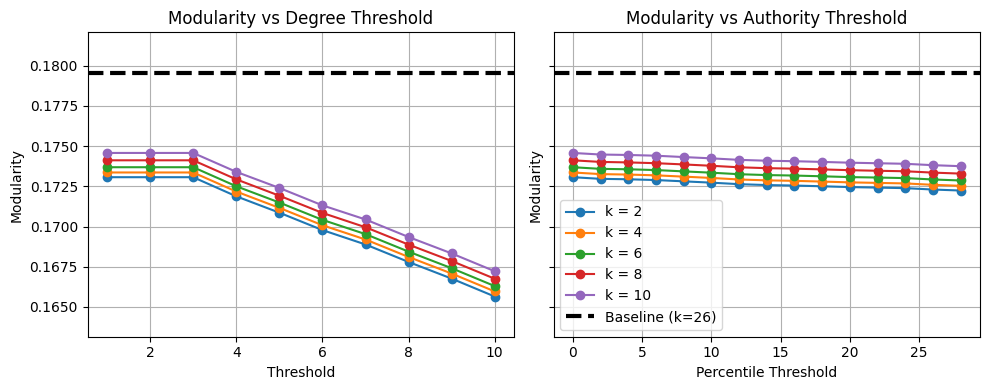

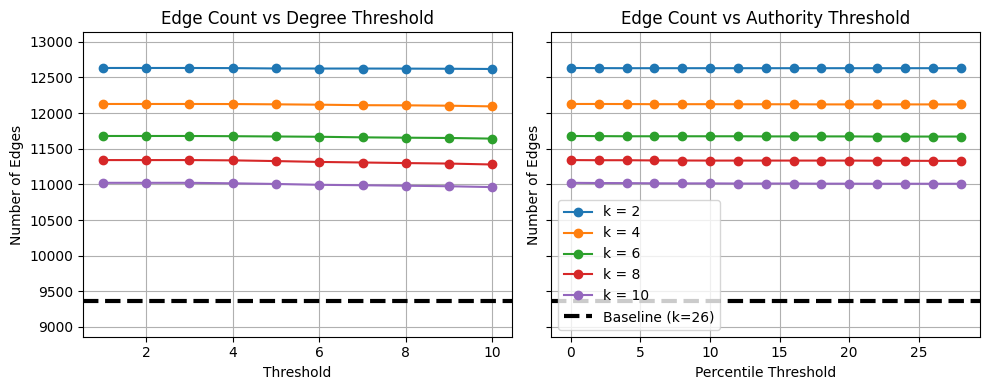

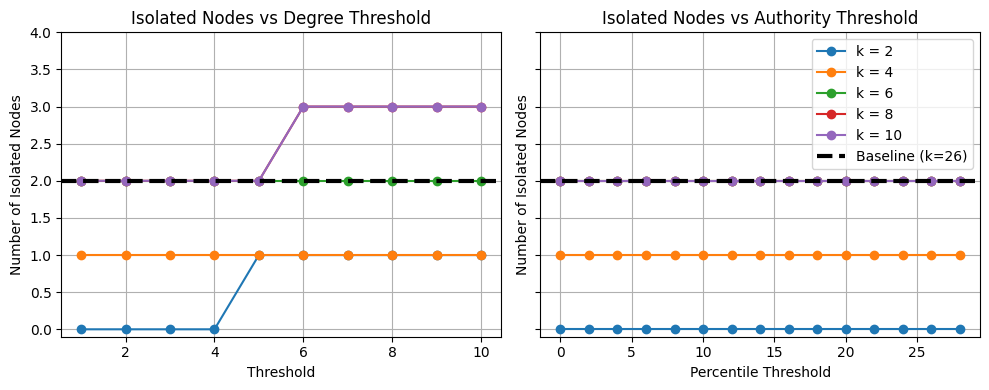

In [273]:
plot_metric_comparison_subplots(results, 'modularity', 'Modularity', 'Modularity')
plot_metric_comparison_subplots(results, 'edge_count', 'Number of Edges', 'Edge Count')
plot_metric_comparison_subplots(results, 'isolated', 'Number of Isolated Nodes', 'Isolated Nodes')


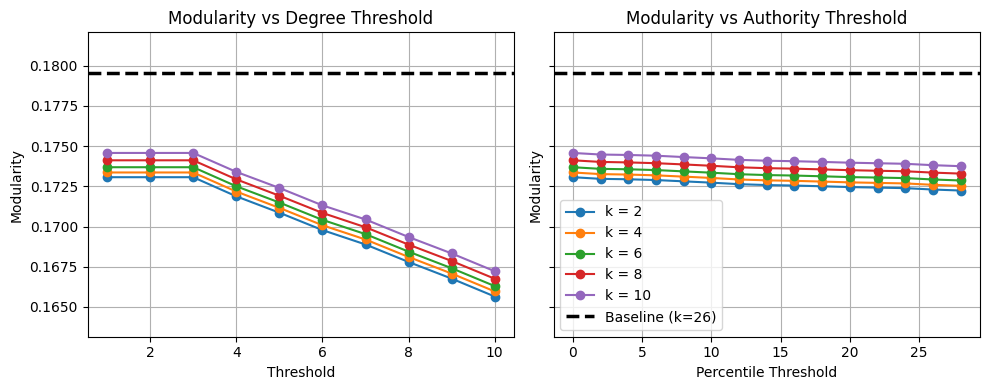

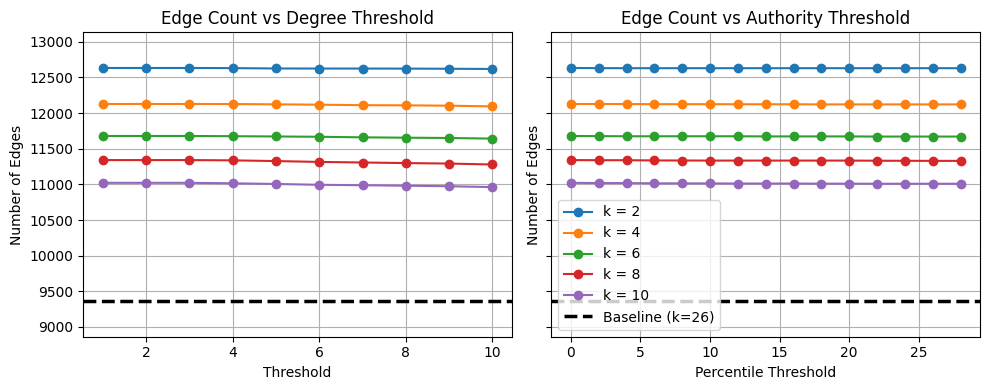

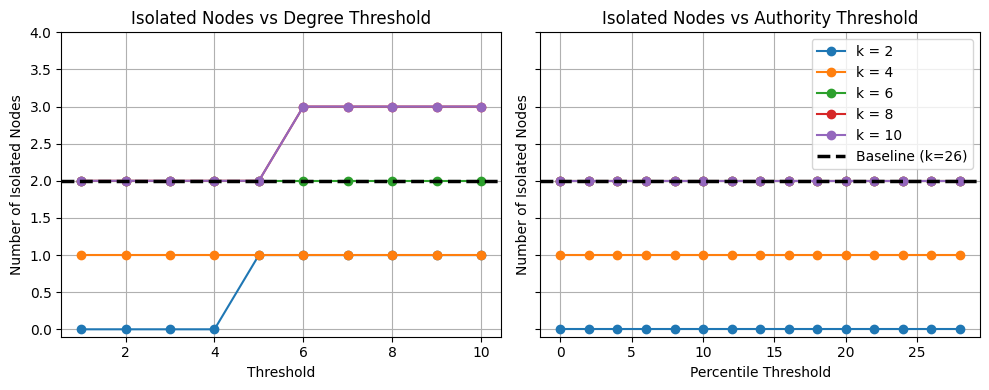

In [241]:
max_k = 12

results_subset = {
    'degree': {k: v for k, v in results['degree'].items() if k <= max_k},
    'authority': {k: v for k, v in results['authority'].items() if k <= max_k},
    'no_filtering': {k: v for k, v in results['no_filtering'].items() if k <= 26}
}

results_subset
plot_metric_comparison_subplots(results_subset, 'modularity', 'Modularity', 'Modularity')
plot_metric_comparison_subplots(results_subset, 'edge_count', 'Number of Edges', 'Edge Count')
plot_metric_comparison_subplots(results_subset, 'isolated', 'Number of Isolated Nodes', 'Isolated Nodes')


34200


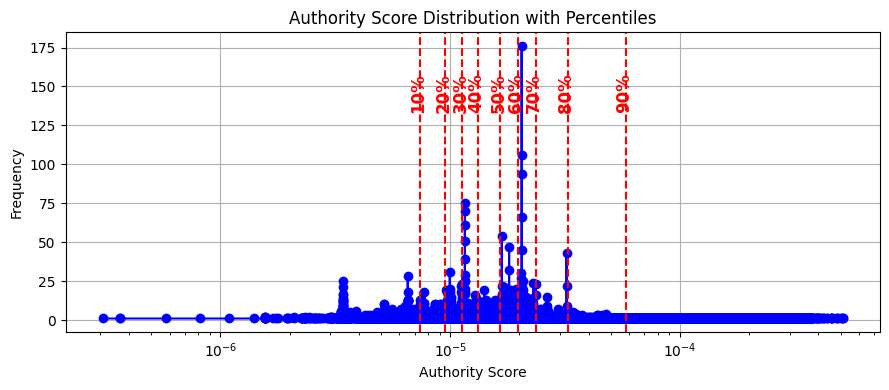

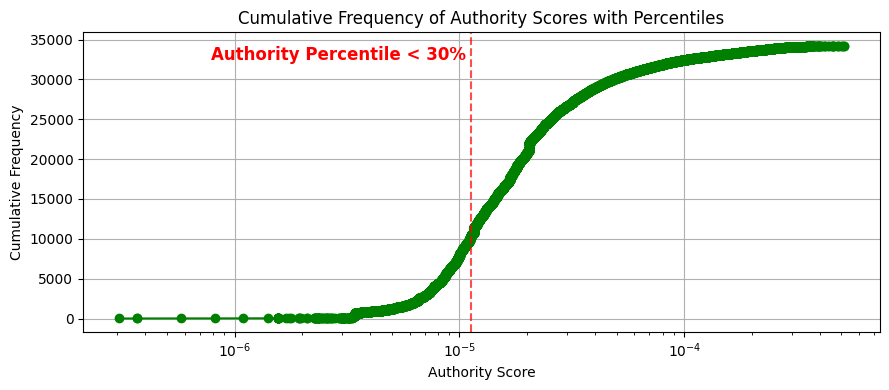

In [285]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

G_directed_old = build_bipartite_network(df_data)
degree_lower_n_remover(df_data, G_directed_old, 2)
G_directed = build_bipartite_network(df_data)
authority_scores, _ = calc_hits_values(G_directed, df_data)
degree_scores = {node: G_directed.degree(node) for node in G_directed.nodes()}

# Assume you already built G_directed, authority_scores etc.

# Authority score list
authority_scores = list(authority_scores.values())
print(len(authority_scores))

# Calculate the frequency of each authority score
authority_score_count = Counter(authority_scores)

# Sort the scores and their frequencies for plotting
sorted_scores = sorted(authority_score_count.keys())
sorted_frequencies = [authority_score_count[score] for score in sorted_scores]
cumulative_frequencies = np.cumsum(sorted_frequencies)

# Define percentiles you want to show
percentiles_to_mark = [10, 20, 30, 40, 50, 60, 70, 80, 90]

# Compute the actual authority score values at those percentiles
percentile_values = np.percentile(authority_scores, percentiles_to_mark)

# --- Plot Frequency Distribution with Percentile Markers ---
plt.figure(figsize=(9, 4))
plt.plot(sorted_scores, sorted_frequencies, marker='o', linestyle='-', color='blue')
plt.xscale('log')
plt.title("Authority Score Distribution with Percentiles")
plt.xlabel("Authority Score")
plt.ylabel("Frequency")
plt.grid(True)

# Mark percentiles
for p_val, perc in zip(percentile_values, percentiles_to_mark):
    plt.axvline(x=p_val, linestyle='--', color='red', alpha=1)
    plt.text(p_val*0.9, max(sorted_frequencies) * 0.9, f'{perc}%', rotation=90, color='red', va='top', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# --- Plot Cumulative Frequency Distribution with Percentile Markers ---
plt.figure(figsize=(9, 4))
plt.plot(sorted_scores, cumulative_frequencies, marker='o', linestyle='-', color='green')
plt.xscale('log')
plt.title("Cumulative Frequency of Authority Scores with Percentiles")
plt.xlabel("Authority Score")
plt.ylabel("Cumulative Frequency")
plt.grid(True)

for p_val, perc in zip(percentile_values, percentiles_to_mark):
    if perc == 30:
        plt.axvline(x=p_val, linestyle='--', color='red', alpha=0.7)
        plt.text(p_val*0.95, max(cumulative_frequencies) * 1, 'Authority Percentile < 30%', rotation=0, color='red', va='top',  ha='right', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


34364
Sample degrees: [226, 74, 63, 63, 9, 30, 3, 40, 37, 70]
Degree count sample: {226: 1, 74: 8, 63: 11, 9: 419, 30: 44, 3: 5854, 40: 34, 37: 28, 70: 5, 58: 14}
[ 2.  2.  2.  2.  2.  3.  4.  5. 10.]


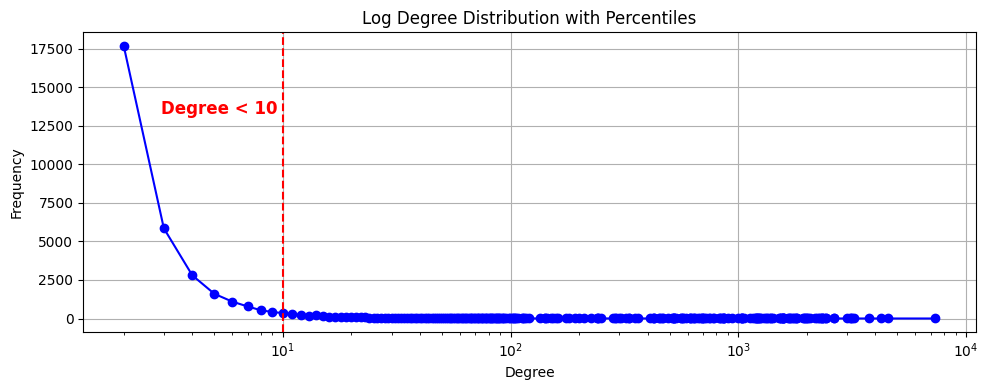

In [286]:
# Step 1: Extract degree list
degrees = list(degree_scores.values())
print(len(degrees))
print("Sample degrees:", degrees[:10])

# Step 2: Count degrees
degree_count = Counter(degrees)
print("Degree count sample:", dict(list(degree_count.items())[:10]))

# Step 3: Sort degrees for plotting
sorted_degrees = sorted(degree_count.keys())
sorted_counts = [degree_count[degree] for degree in sorted_degrees]

# Step 4: Calculate degree percentiles
percentiles_to_mark = [10, 20, 30, 40, 50, 60, 70, 80, 90]
percentile_values = np.percentile(degrees, percentiles_to_mark)
print(percentile_values)

# Step 5: Plot
plt.figure(figsize=(10, 4))
plt.plot(sorted_degrees, sorted_counts, marker='o', linestyle='-', color='blue')
# plt.yscale('log')
plt.xscale('log')
plt.title("Log Degree Distribution with Percentiles")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.grid(True)

# # Step 6: Add red dashed percentile lines

from collections import defaultdict
import numpy as np

# Step 1: Group percentiles by identical degree value (rounded cleanly)
pval_to_percs = defaultdict(list)
for p_val, perc in zip(percentile_values, percentiles_to_mark):
    rounded_val = int(round(p_val))  # round for cleaner display
    pval_to_percs[rounded_val].append(perc)

# Step 2: Plot vertical lines & combined labels
for p_val, perc_list in sorted(pval_to_percs.items()):
    if perc_list[0] == 90:
        plt.axvline(x=p_val, linestyle='--', color='red', alpha=1)

        # Combine all percentiles at this value into one label
        label_str = ", ".join(f"{p}%" for p in perc_list)
        plt.text(p_val*0.95, max(sorted_counts) * 0.8, "Degree < 10",
                rotation=0, color='red', va='top', ha='right', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()


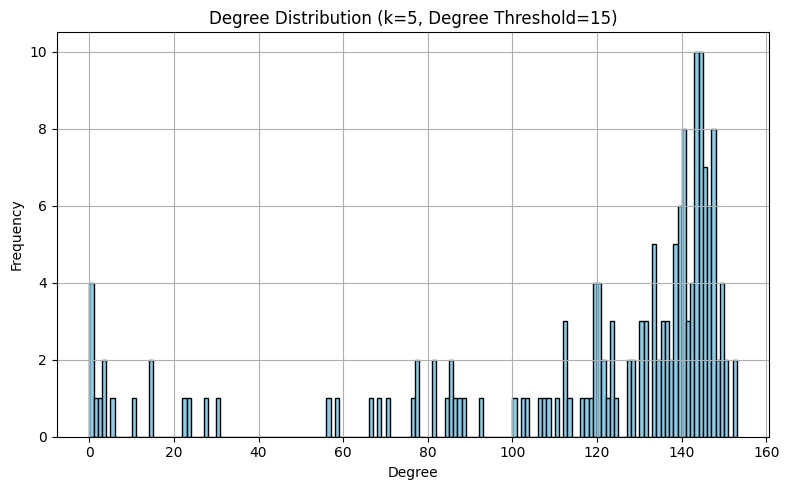

In [245]:
df_data, republican_df, democratic_df = read_data(-1)
G_directed = build_bipartite_network(df_data)
# Step 2: Calculate degree and filter followees
degree_scores = {node: G_directed.degree(node) for node in G_directed.nodes()}
filtered_followees = {node for node, deg in degree_scores.items() if deg >= 3}

# Step 3: Apply filtering to followings
df_data['important_following'] = df_data['following'].apply(
    lambda f_list: [f for f in f_list if f in filtered_followees]
)

# Step 4: Build shared-following network with threshold k=5
G_shared = build_network(df_data, k=23, hits=True, weighted=True)

# Step 5: Plot degree distribution
degrees = [d for n, d in G_shared.degree()]
plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=range(min(degrees), max(degrees) + 1), color='skyblue', edgecolor='black')
plt.title("Degree Distribution (k=5, Degree Threshold=15)")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()